# Задача 6. Вычисление $P^k$ и предельное распределение

**Цель:** проверить сходимость к стационарному распределению.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#матрица переходов из задания 5
nucleotides = ['A', 'C', 'G', 'T']

P = np.array([
    [0.371528, 0.122790, 0.196654, 0.309028],  # из A
    [0.313514, 0.173574, 0.156757, 0.356156],  # из C
    [0.355844, 0.199481, 0.187532, 0.257143],  # из G
    [0.242209, 0.185745, 0.209812, 0.362234],  # из T
])

In [3]:
k_values = list(range(1, 1001))
norms = []

P_prev = np.eye(4)  # P^0 = единичная матрица

for k in k_values:
    P_k = np.linalg.matrix_power(P, k)
    norm = np.linalg.norm(P_k - P_prev, 'fro')
    norms.append(norm)
    P_prev = P_k


In [7]:
#я выведу не для всех k, чтобы было проще анализировать визуально - выведу для начальных и затем увеличу шаг
print("Как меняются строки P^k с ростом k:")

for k in [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 70,  100, 500, 1000]:
    Pk = np.linalg.matrix_power(P, k)
    print(f"\nP^{k}:")
    print(f"  {'':4}", ''.join(f'{s:>10}' for s in nucleotides))
    for i, row in enumerate(Pk):
        print(f"  {nucleotides[i]}:  ", '  '.join(f'{v:.6f}' for v in row))

Как меняются строки P^k с ростом k:

P^1:
                A         C         G         T
  A:   0.371528  0.122790  0.196654  0.309028
  C:   0.313514  0.173574  0.156757  0.356156
  G:   0.355844  0.199481  0.187532  0.257143
  T:   0.242209  0.185745  0.209812  0.362234

P^2:
                A         C         G         T
  A:   0.321357  0.163562  0.194027  0.321054
  C:   0.312942  0.166049  0.192985  0.328025
  G:   0.323761  0.163491  0.190368  0.322381
  T:   0.310618  0.171118  0.192096  0.326169

P^3:
                A         C         G         T
  A:   0.317478  0.166188  0.192583  0.323751
  C:   0.316449  0.166674  0.192585  0.324294
  G:   0.317368  0.165988  0.192637  0.324008
  T:   0.316408  0.166746  0.192366  0.324480

P^4:
                A         C         G         T
  A:   0.316999  0.166381  0.192527  0.324094
  C:   0.316901  0.166440  0.192515  0.324146
  G:   0.316977  0.166391  0.192538  0.324095
  T:   0.316876  0.166438  0.192516  0.324170

P^5:
      

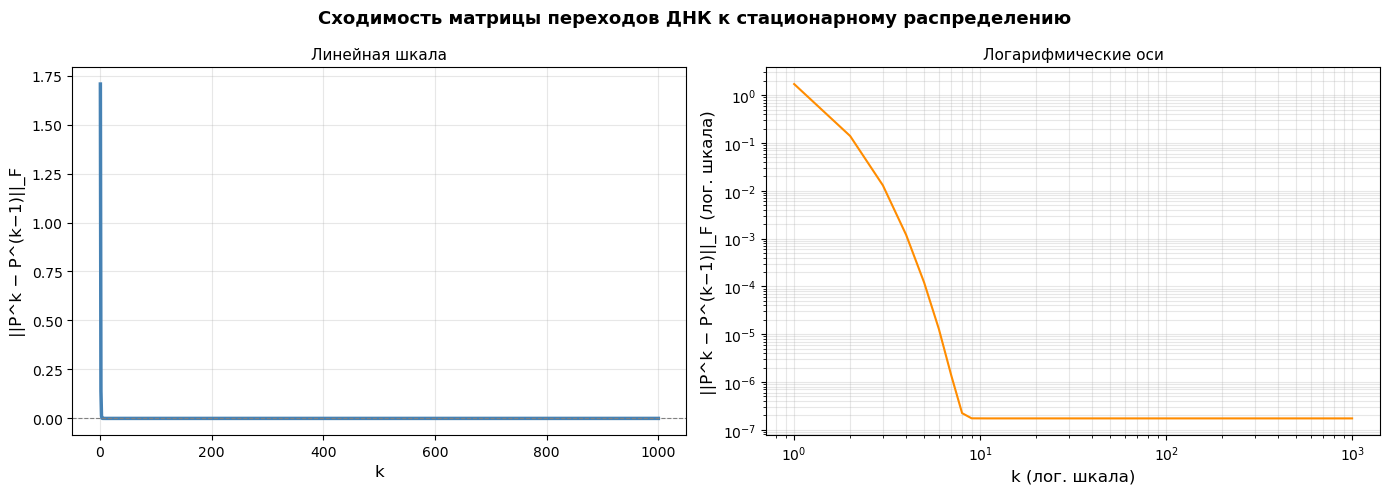

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сходимость матрицы переходов ДНК к стационарному распределению',
             fontsize=13, fontweight='bold')

#линейная шкала
ax1 = axes[0]
ax1.plot(k_values, norms, color='steelblue', linewidth=2.5)
ax1.fill_between(k_values, norms, alpha=0.15, color='steelblue')
ax1.set_xlabel('k', fontsize=12)
ax1.set_ylabel('||P^k − P^(k−1)||_F', fontsize=12)
ax1.set_title('Линейная шкала', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')

#логарифмическая шкала
ax2 = axes[1]
ax2.plot(k_values, norms, color='darkorange', linewidth=1.5)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('k (лог. шкала)', fontsize=12)
ax2.set_ylabel('||P^k − P^(k−1)||_F (лог. шкала)', fontsize=12)
ax2.set_title('Логарифмические оси', fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

видим, что матрица очень быстро стабилизируется - посмотрим при меньших k - где стабилизируется 

Стабилизация при k ≈ 8 (норма < 1e-06)


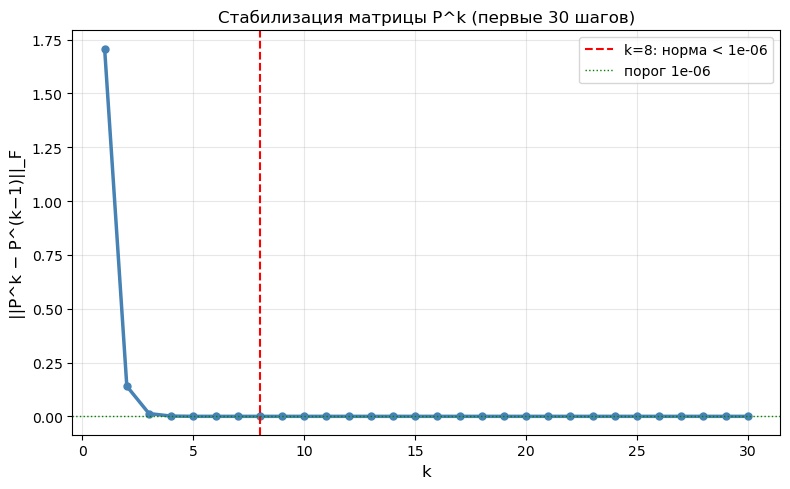

In [24]:
threshold = 1e-6
stab_k = next((k for k, n in zip(k_values, norms) if n < threshold), None)
print(f"Стабилизация при k ≈ {stab_k} (норма < {threshold})")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values[:30], norms[:30], color='steelblue', linewidth=2.5,
        marker='o', markersize=5)
ax.axvline(stab_k, color='red', linewidth=1.5, linestyle='--',
           label=f'k={stab_k}: норма < {threshold}')
ax.axhline(threshold, color='green', linewidth=1, linestyle=':',
           label=f'порог {threshold}')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('||P^k − P^(k−1)||_F', fontsize=12)
ax.set_title('Стабилизация матрицы P^k (первые 30 шагов)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_exact = np.real(eigenvectors[:, idx])
pi_exact = pi_exact / pi_exact.sum()

print("Стационарное распределение π:")
print('  ' + ''.join(f'{s:>10}' for s in nucleotides))
print('  ' + '  '.join(f'{v:.8f}' for v in pi_exact))

print("Строки P^k при разных k — проверяем сходимость:")

check_ks = [900, 925, 950, 975, 1000]

for k in check_ks:
    Pk = np.linalg.matrix_power(P, k)
    print(f"\nP^{k}:")
    print('  ' + ''.join(f'{s:>10}' for s in nucleotides))
    for i, row in enumerate(Pk):
        print(f"  {nucleotides[i]}:  " + '  '.join(f'{v:.8f}' for v in row))
    
    #насколько строки отличаются от π
    diff_from_pi = np.max(np.abs(Pk - pi_exact))
    print(f"  → макс. отклонение от π точного: {diff_from_pi:.2e}")


Стационарное распределение π:
           A         C         G         T
  0.31693845  0.16641122  0.19252332  0.32412700
Строки P^k при разных k — проверяем сходимость:

P^900:
           A         C         G         T
  A:  0.31698585  0.16643611  0.19255212  0.32417548
  C:  0.31698619  0.16643629  0.19255232  0.32417582
  G:  0.31698588  0.16643612  0.19255213  0.32417551
  T:  0.31698588  0.16643612  0.19255213  0.32417550
  → макс. отклонение от π точного: 4.88e-05

P^925:
           A         C         G         T
  A:  0.31698717  0.16643680  0.19255292  0.32417683
  C:  0.31698751  0.16643698  0.19255312  0.32417717
  G:  0.31698720  0.16643682  0.19255294  0.32417686
  T:  0.31698720  0.16643682  0.19255293  0.32417685
  → макс. отклонение от π точного: 5.02e-05

P^950:
           A         C         G         T
  A:  0.31698849  0.16643750  0.19255372  0.32417818
  C:  0.31698883  0.16643767  0.19255393  0.32417852
  G:  0.31698852  0.16643751  0.19255374  0.32417820
  T:  

Убеждаемся, что строки совпадают со стационарным распределнием $\pi$ - ошибка немного растет при росте k - она свазяна с накоплением ошибок числовой точности